In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.cuda.amp import GradScaler
from torch.cuda.amp import autocast
from torchvision import transforms
import pandas as pd
import numpy as np
from PIL import Image
import os 
import json
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import random
import gc

In [17]:
gc.collect()
torch.cuda.empty_cache()

Фиксация seed

In [18]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

Архитектура

In [19]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=kernel_size, 
                                   padding=padding, groups=in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        
    def forward(self, x):
        return self.pointwise(self.depthwise(x))

class SqueezeExcitationBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.global_avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class FaceAntiDeepfakeNet(nn.Module):
    def __init__(self, num_classes=2, input_channels=3):
        super().__init__()
        
        self.stem = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        
        self.block1 = nn.Sequential(
            DepthwiseSeparableConv(32, 64),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            SqueezeExcitationBlock(64),
            nn.MaxPool2d(2)
        )
        
        self.block2_conv = nn.Sequential(
            DepthwiseSeparableConv(64, 128),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            DepthwiseSeparableConv(128, 128),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        self.block2_se = SqueezeExcitationBlock(128)
        self.block2_pool = nn.MaxPool2d(2)
        self.block2_residual = nn.Conv2d(64, 128, kernel_size=1, stride=2)
        
        self.block3 = nn.Sequential(
            DepthwiseSeparableConv(128, 256),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            DepthwiseSeparableConv(256, 256),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            SqueezeExcitationBlock(256),
            nn.MaxPool2d(2)
        )
        
        self.block4 = nn.Sequential(
            DepthwiseSeparableConv(256, 512),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.2),
            nn.MaxPool2d(2)
        )
        
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        
        residual = self.block2_residual(x)
        x = self.block2_conv(x)
        x = self.block2_se(x)
        x = self.block2_pool(x)
        x = x + residual
        
        x = self.block3(x)
        x = self.block4(x)
        
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        
        return x

Трансформации

In [20]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

Dataset

In [21]:
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['Id']
        label = self.df.iloc[idx]['target_feature']
        path = os.path.join(self.img_dir, img_name)
        
        try:
            image = Image.open(path).convert('RGB')
        except (FileNotFoundError, OSError):
            image = Image.new('RGB', (224, 224), color='gray')
        
        if self.transform:
            image = self.transform(image)
        
        return image, torch.tensor(label, dtype=torch.long)

Загрузка данных

In [22]:
train_df = pd.read_csv('train_solution.csv', header=None)
train_df.columns = ['Id', 'target_feature']

if not str(train_df['Id'].iloc[0]).endswith('.jpg'):
    train_df['Id'] = train_df['Id'].astype(str) + '.jpg'

print(f"Загружено {len(train_df)} примеров")
print(f"Распределение классов:\n{train_df['target_feature'].value_counts()}")

labels = train_df['target_feature'].values
train_idx, val_idx = train_test_split(
    range(len(train_df)), 
    test_size=0.2, 
    stratify=labels,
    random_state=42
)

train_dataset = CustomDataset(train_df.iloc[train_idx], 'train_images', transform=train_transform)
val_dataset = CustomDataset(train_df.iloc[val_idx], 'train_images', transform=val_transform)

Загружено 50000 примеров
Распределение классов:
target_feature
0    41500
1     8500
Name: count, dtype: int64


DataLoader с балансировкой

In [23]:
train_labels_list = train_dataset.df['target_feature'].values
class_counts = np.bincount(train_labels_list)

class_weights = torch.FloatTensor([1.0 / class_counts[0], 1.0 / class_counts[1]])
class_weights = class_weights / class_weights.sum()

print(f"Class distribution in train:")
print(f"  Class 0 (real): {class_counts[0]} samples")
print(f"  Class 1 (fake): {class_counts[1]} samples")
print(f"  Class weights: class_0={class_weights[0]:.4f}, class_1={class_weights[1]:.4f}")
print(f"  Effective weight ratio: {class_weights[1]/class_weights[0]:.2f}x for fake class")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

batch_size = 128
num_workers = 0

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=num_workers, 
    pin_memory=False,
    drop_last=False
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=num_workers, 
    pin_memory=False,
    drop_last=False
)

print(f"Train batches: {len(train_loader)} (samples: {len(train_dataset)})")
print(f"Val batches: {len(val_loader)} (samples: {len(val_dataset)})")

Class distribution in train:
  Class 0 (real): 33200 samples
  Class 1 (fake): 6800 samples
  Class weights: class_0=0.1700, class_1=0.8300
  Effective weight ratio: 4.88x for fake class
Device: cuda
Train batches: 313 (samples: 40000)
Val batches: 79 (samples: 10000)


Инициализация модели

In [24]:
model = FaceAntiDeepfakeNet(num_classes=2).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)

scaler = GradScaler() if device.type == 'cuda' else None

Total parameters: 471,138
Trainable parameters: 471,138


C:\Users\Gigabyte G6X\AppData\Local\Temp\ipykernel_5720\1383324591.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if device.type == 'cuda' else None


Функции обучения

In [25]:
def train_epoch(model, loader, criterion, optimizer, device, scaler=None):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    pbar = tqdm(loader, desc='Training', leave=False)
    
    for batch_idx, (images, labels) in enumerate(pbar):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        if scaler is not None and device.type == 'cuda':
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        
        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        current_loss = running_loss / (batch_idx + 1)
        pbar.set_postfix({'loss': f'{current_loss:.4f}'})
    
    epoch_loss = running_loss / len(loader)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    
    return epoch_loss, precision, recall, f1


def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    pbar = tqdm(loader, desc='Validation', leave=False)
    
    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(pbar):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            current_loss = running_loss / (batch_idx + 1)
            pbar.set_postfix({'loss': f'{current_loss:.4f}'})
    
    epoch_loss = running_loss / len(loader)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    
    return epoch_loss, precision, recall, f1, all_labels, all_preds

Обучение

In [26]:
num_epochs = 32
best_f1 = 0.0
history = {
    'train_loss': [], 'val_loss': [],
    'train_precision': [], 'val_precision': [],
    'train_recall': [], 'val_recall': [],
    'train_f1': [], 'val_f1': [],
    'lr': []
}

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    train_loss, train_prec, train_rec, train_f1 = train_epoch(
        model, train_loader, criterion, optimizer, device, scaler
    )
    
    val_loss, val_prec, val_rec, val_f1, val_labels, val_preds = validate_epoch(
        model, val_loader, criterion, device
    )
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_precision'].append(train_prec)
    history['val_precision'].append(val_prec)
    history['train_recall'].append(train_rec)
    history['val_recall'].append(val_rec)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)
    history['lr'].append(optimizer.param_groups[0]['lr'])
    
    print(f"Train - Loss: {train_loss:.4f}, P: {train_prec:.4f}, R: {train_rec:.4f}, F1: {train_f1:.4f}")
    print(f"Val   - Loss: {val_loss:.4f}, P: {val_prec:.4f}, R: {val_rec:.4f}, F1: {val_f1:.4f}")
    
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_f1': best_f1,
            'history': history
        }, 'best_model.pth')
        
        print(f"New best model saved (F1: {best_f1:.4f})")
    
    scheduler.step()
    
    if device.type == 'cuda':
        gpu_mem = torch.cuda.memory_allocated() / 1e9
        gpu_mem_cached = torch.cuda.memory_reserved() / 1e9
        print(f"GPU Memory: {gpu_mem:.2f} GB used, {gpu_mem_cached:.2f} GB cached")

print(f"\nTraining Complete")
print(f"Best F1 Score: {best_f1:.4f}")


Epoch 1/32
LR: 0.001000


Training:   0%|          | 0/313 [00:00<?, ?it/s]C:\Users\Gigabyte G6X\AppData\Local\Temp\ipykernel_5720\4062446056.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Train - Loss: 0.6803, P: 0.2109, R: 0.5376, F1: 0.3029
Val   - Loss: 0.6555, P: 0.2428, R: 0.6735, F1: 0.3569
New best model saved (F1: 0.3569)
GPU Memory: 0.04 GB used, 7.15 GB cached

Epoch 2/32
LR: 0.000905


Training:   0%|          | 0/313 [00:00<?, ?it/s]C:\Users\Gigabyte G6X\AppData\Local\Temp\ipykernel_5720\4062446056.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Train - Loss: 0.6315, P: 0.2728, R: 0.6454, F1: 0.3835
Val   - Loss: 0.6175, P: 0.2696, R: 0.7500, F1: 0.3966
New best model saved (F1: 0.3966)
GPU Memory: 0.04 GB used, 7.15 GB cached

Epoch 3/32
LR: 0.000655


...

Train - Loss: 0.1140, P: 0.8038, R: 0.9568, F1: 0.8736
Val   - Loss: 0.1860, P: 0.8462, R: 0.9094, F1: 0.8767
New best model saved (F1: 0.8767)
GPU Memory: 0.04 GB used, 7.15 GB cached

Epoch 31/32
LR: 0.000146


Training:   0%|          | 0/313 [00:00<?, ?it/s]C:\Users\Gigabyte G6X\AppData\Local\Temp\ipykernel_5720\4062446056.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Train - Loss: 0.1060, P: 0.8111, R: 0.9644, F1: 0.8812
Val   - Loss: 0.1662, P: 0.7777, R: 0.9382, F1: 0.8504
GPU Memory: 0.04 GB used, 7.15 GB cached

Epoch 32/32
LR: 0.000095


Training:   0%|          | 0/313 [00:00<?, ?it/s]C:\Users\Gigabyte G6X\AppData\Local\Temp\ipykernel_5720\4062446056.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
                                                                        

Train - Loss: 0.1006, P: 0.8285, R: 0.9643, F1: 0.8913
Val   - Loss: 0.1952, P: 0.8657, R: 0.9065, F1: 0.8856
New best model saved (F1: 0.8856)
GPU Memory: 0.04 GB used, 7.15 GB cached

Training Complete
Best F1 Score: 0.8856


Визуализации

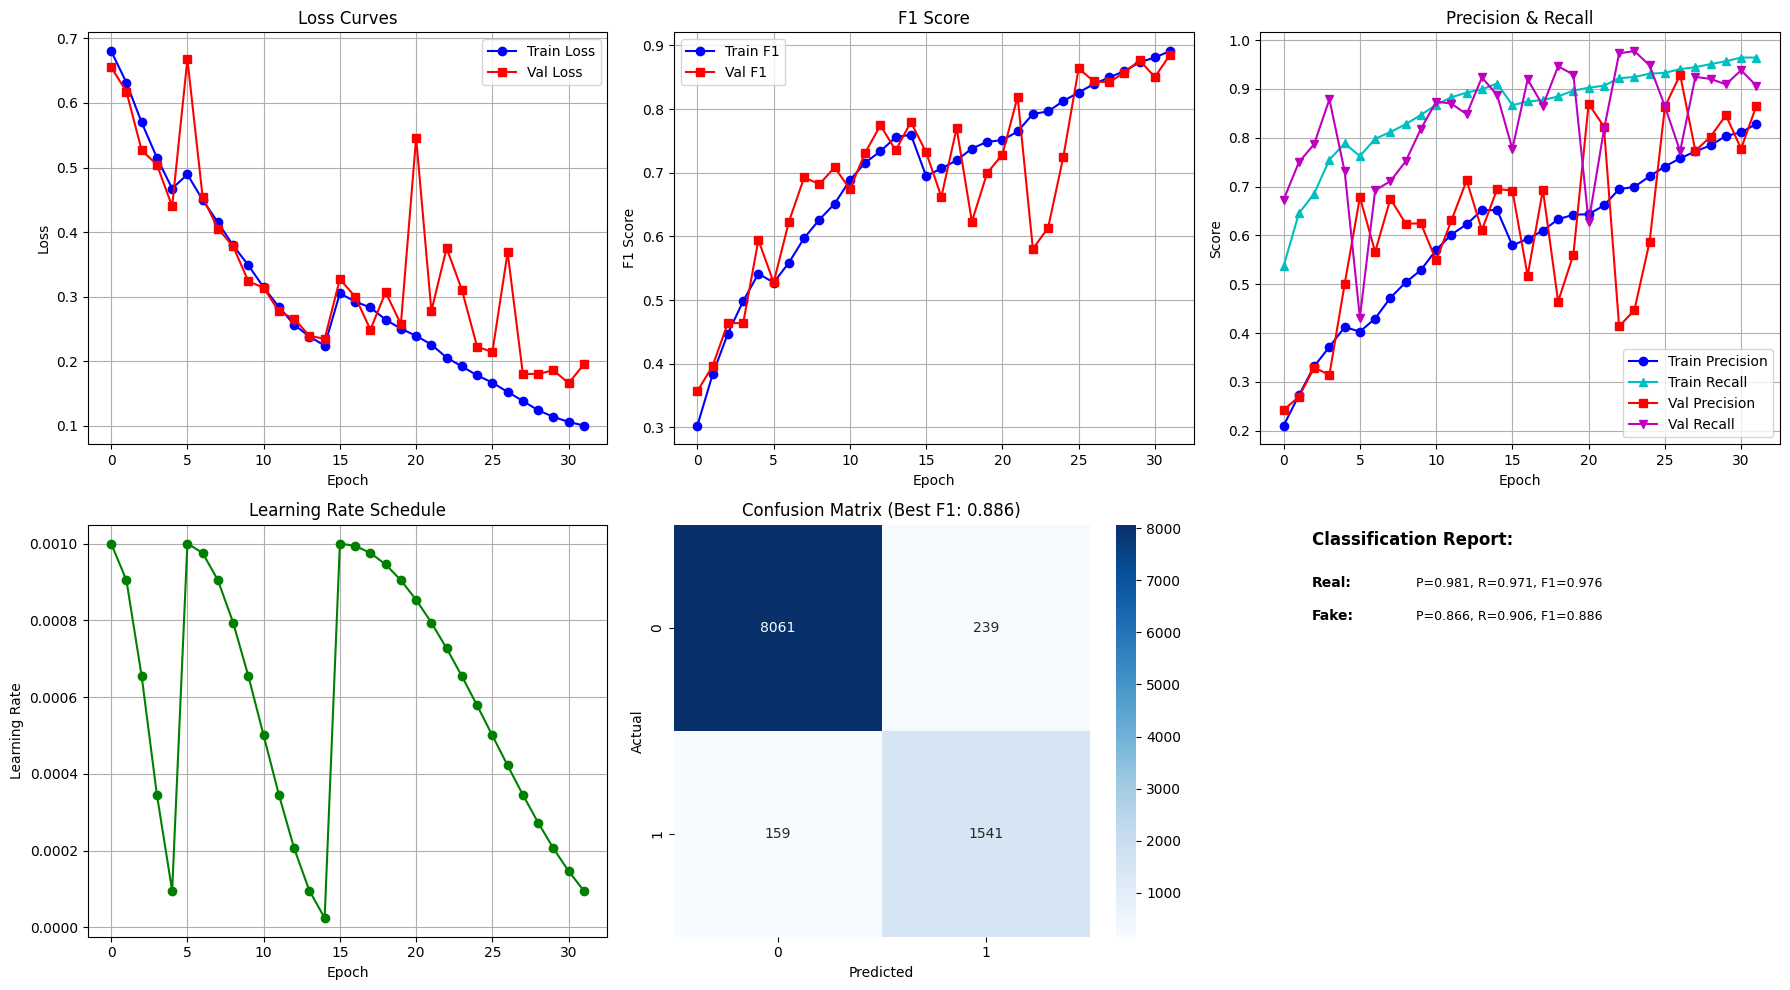


Classification Report:
              precision    recall  f1-score   support

        Real       0.98      0.97      0.98      8300
        Fake       0.87      0.91      0.89      1700

    accuracy                           0.96     10000
   macro avg       0.92      0.94      0.93     10000
weighted avg       0.96      0.96      0.96     10000



In [27]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].plot(history['train_loss'], 'b-o', label='Train Loss')
axes[0, 0].plot(history['val_loss'], 'r-s', label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curves')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(history['train_f1'], 'b-o', label='Train F1')
axes[0, 1].plot(history['val_f1'], 'r-s', label='Val F1')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('F1 Score')
axes[0, 1].set_title('F1 Score')
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[0, 2].plot(history['train_precision'], 'b-o', label='Train Precision')
axes[0, 2].plot(history['train_recall'], 'c-^', label='Train Recall')
axes[0, 2].plot(history['val_precision'], 'r-s', label='Val Precision')
axes[0, 2].plot(history['val_recall'], 'm-v', label='Val Recall')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Score')
axes[0, 2].set_title('Precision & Recall')
axes[0, 2].legend()
axes[0, 2].grid(True)

axes[1, 0].plot(history['lr'], 'g-o')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].set_title('Learning Rate Schedule')
axes[1, 0].grid(True)

checkpoint = torch.load('best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
_, _, _, _, val_labels_final, val_preds_final = validate_epoch(model, val_loader, criterion, device)

cm = confusion_matrix(val_labels_final, val_preds_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1])
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Actual')
axes[1, 1].set_title(f'Confusion Matrix (Best F1: {best_f1:.3f})')

report = classification_report(val_labels_final, val_preds_final, 
                               target_names=['Real', 'Fake'], output_dict=True)
axes[1, 2].axis('off')
axes[1, 2].text(0.1, 0.95, 'Classification Report:', fontsize=12, fontweight='bold')
y_pos = 0.85
for class_name, metrics in report.items():
    if class_name not in ['accuracy', 'macro avg', 'weighted avg']:
        axes[1, 2].text(0.1, y_pos, f"{class_name}:", fontsize=10, fontweight='bold')
        axes[1, 2].text(0.3, y_pos, f"P={metrics['precision']:.3f}, R={metrics['recall']:.3f}, F1={metrics['f1-score']:.3f}", fontsize=9)
        y_pos -= 0.08

plt.tight_layout()
plt.savefig('training_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nClassification Report:")
print(classification_report(val_labels_final, val_preds_final, target_names=['Real', 'Fake']))

Тестовые предсказания

In [28]:
test_files = sorted([f for f in os.listdir('test_images') if f.endswith(('.jpg', '.png', '.jpeg'))])
print(f"\nFound {len(test_files)} test images")

class TestDataset(torch.utils.data.Dataset):
    def __init__(self, file_list, img_dir, transform=None):
        self.file_list = file_list
        self.img_dir = img_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.file_list)
    
    def __getitem__(self, idx):
        img_name = self.file_list[idx]
        path = os.path.join(self.img_dir, img_name)
        try:
            image = Image.open(path).convert('RGB')
        except:
            image = Image.new('RGB', (224, 224), color='gray')
        
        name_without_ext = os.path.splitext(img_name)[0] 
        
        if self.transform:
            image = self.transform(image)
        return image, name_without_ext

test_dataset = TestDataset(test_files, 'test_images', transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, 
                         num_workers=num_workers, pin_memory=(device.type=='cuda'))

model.eval()
predictions = []
image_names = []

with torch.no_grad():
    for images, names in tqdm(test_loader, desc='Predicting test'):
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        predictions.extend(preds.cpu().numpy())
        image_names.extend(names)

submission_df = pd.DataFrame({
    'Id': image_names,
    'target_feature': predictions
})

submission_df.to_csv('submission.csv', index=False, header=True)
print("\nSubmission saved: submission.csv")
print(f"Sample of submission:\n{submission_df.head()}")


Found 10000 test images


Predicting test: 100%|██████████| 157/157 [00:33<00:00,  4.69it/s]


Submission saved: submission.csv
Sample of submission:
     Id  target_feature
0     0               0
1     1               0
2    10               0
3   100               0
4  1000               0


Сохранение мета-информации

In [29]:
metadata = {
    'best_f1': float(best_f1),
    'num_epochs': num_epochs,
    'batch_size': batch_size,
    'learning_rate': 1e-3,
    'optimizer': 'AdamW',
    'scheduler': 'CosineAnnealingWarmRestarts',
    'model_parameters': total_params,
    'trainable_parameters': trainable_params,
    'architecture': 'FaceAntiDeepfakeNet',
    'unique_components': ['DepthwiseSeparableConv', 'SqueezeExcitationBlock', 'ResidualConnections'],
    'final_train_f1': float(history['train_f1'][-1]),
    'final_val_f1': float(history['val_f1'][-1])
}

with open('training_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("\nMetadata saved: training_metadata.json")

print("Training Complete!")
print(f"Best Validation F1: {best_f1:.4f}")
print("Files saved: best_model.pth, submission.csv, training_plots.png, training_metadata.json")


Metadata saved: training_metadata.json
Training Complete!
Best Validation F1: 0.8856
Files saved: best_model.pth, submission.csv, training_plots.png, training_metadata.json
